<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/15_decision_tree_overfitting_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Overfitting Analysis

In this notebook, we compare shallow and deep Decision Trees to understand model complexity and overfitting behavior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1,
    random_state=42
)

In [3]:
shallow_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

shallow_tree.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [4]:
deep_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

deep_tree.fit(X, y)

DecisionTreeClassifier(max_depth=10, random_state=42)

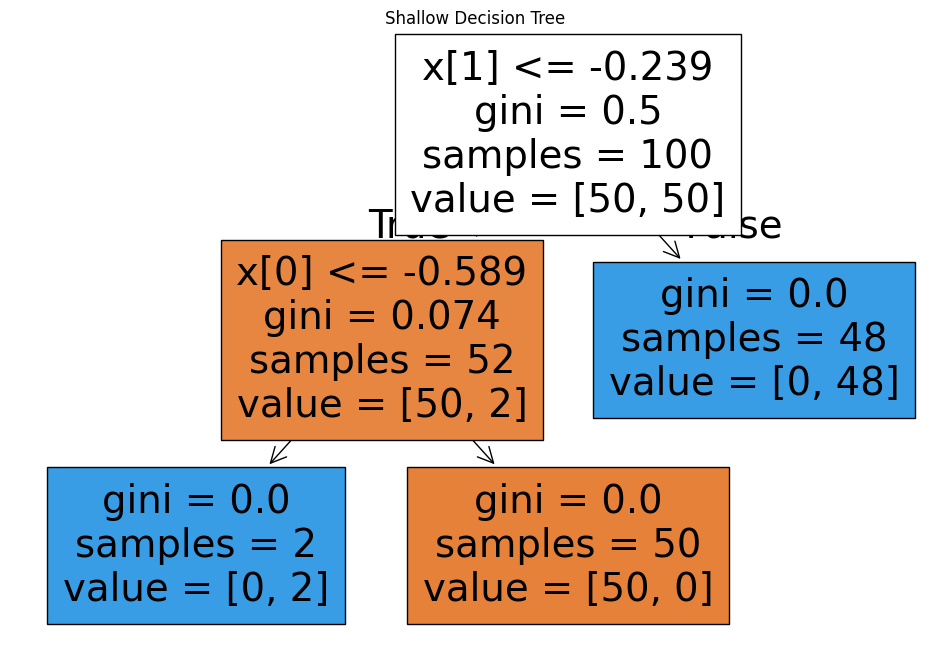

In [5]:
plt.figure(figsize=(12,8))

plot_tree(
    shallow_tree,
    filled=True
)

plt.title("Shallow Decision Tree")

plt.show()

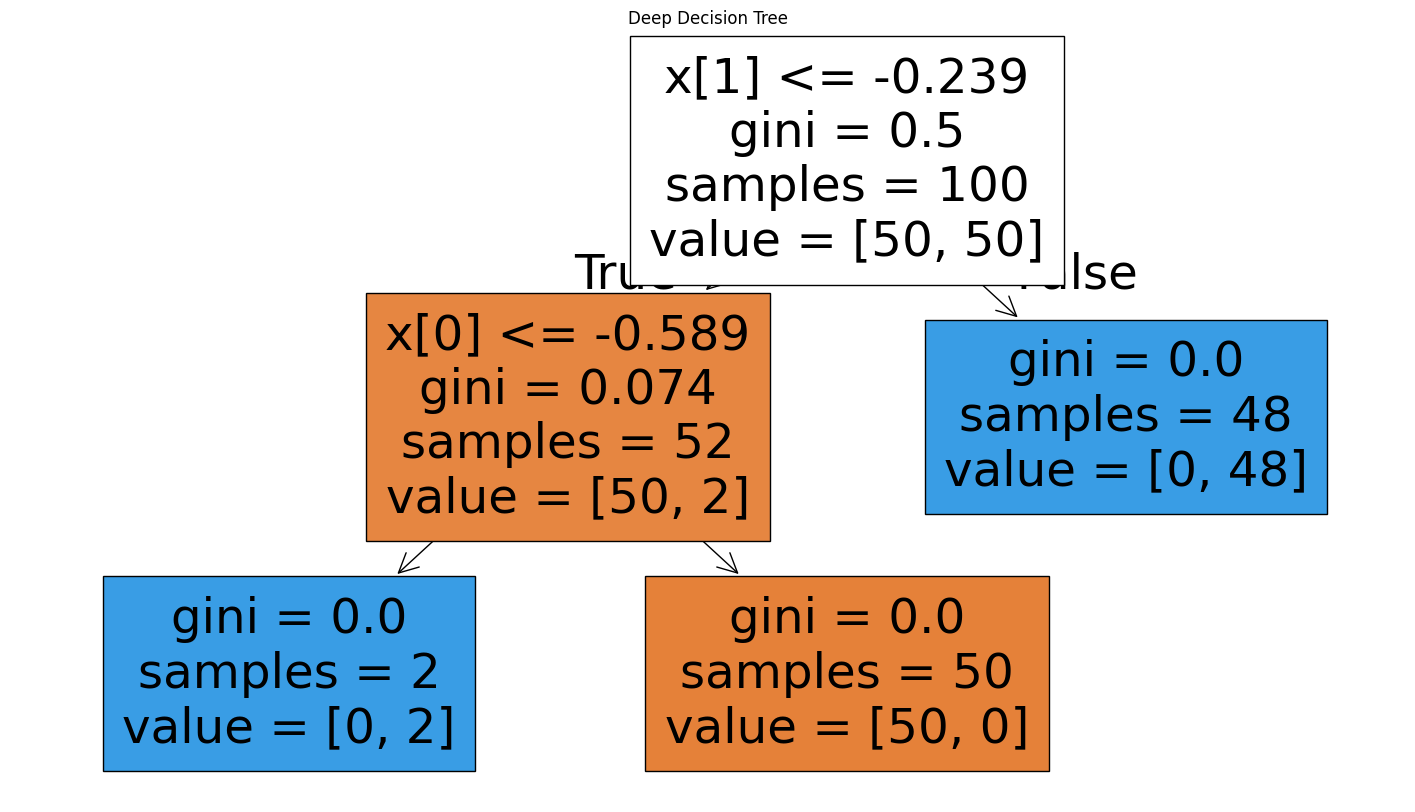

In [6]:
plt.figure(figsize=(18,10))

plot_tree(
    deep_tree,
    filled=True
)

plt.title("Deep Decision Tree")

plt.show()

In [7]:
print(
    "Shallow Tree Accuracy:",
    shallow_tree.score(X, y)
)

print(
    "Deep Tree Accuracy:",
    deep_tree.score(X, y)
)

Shallow Tree Accuracy: 1.0
Deep Tree Accuracy: 1.0


In [8]:
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

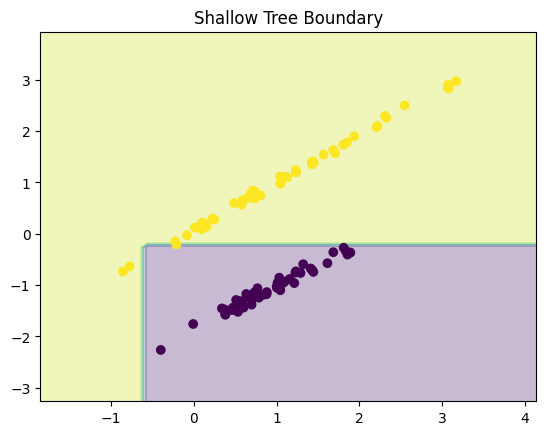

In [9]:
Z1 = shallow_tree.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z1 = Z1.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z1, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y)

plt.title("Shallow Tree Boundary")

plt.show()

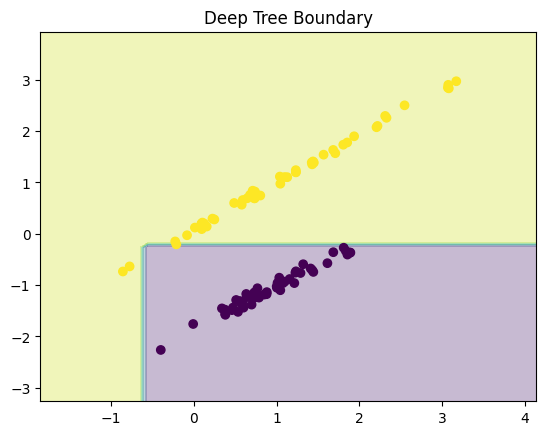

In [10]:
Z2 = deep_tree.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z2 = Z2.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z2, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y)

plt.title("Deep Tree Boundary")

plt.show()